# Expérimentations SVM — dataset déchets

In [1]:
import sys
import os

SVM_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(SVM_DIR, ".."))

sys.path.insert(0, SVM_DIR)
sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
from svm_lib import SVM_OVR, SVM_HARD_MARGIN
from charger_dataset import charger_config

In [2]:
def afficher_matrice_confusion(cm, titre, classes, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    n = len(classes)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel("Classe predite")
    ax.set_ylabel("Classe reelle")
    ax.set_title(titre, fontsize=10)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)

    return ax

## Chargement du dataset (config de base : 32x32 RGB)

In [3]:
CONFIG = "32x32_rgb"

X_train, y_train, X_val, y_val, X_test, y_test, classes = charger_config(CONFIG)

N_CLASSES  = len(classes)
N_FEATURES = X_train.shape[1]

print(f"Config         : {CONFIG}")
print(f"Classes        : {classes}")
print(f"N_FEATURES     : {N_FEATURES}")
print(f"N_CLASSES      : {N_CLASSES}")
print()
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    (garde pour la fin)")


Config     : 32x32_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 3072)  y_train : (4960,)
  X_val   : (1062, 3072)    y_val   : (1062,)
  X_test  : (1066, 3072)   y_test  : (1066,)
  n_features = 3072
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

Config         : 32x32_rgb
Classes        : ['compost', 'dechets_chimiques', 'recyclable']
N_FEATURES     : 3072
N_CLASSES      : 3

X_train : (4960, 3072)   y_train : (4960,)
X_val   : (1062, 3072)     y_val   : (1062,)
X_test  : (1066, 3072)    (garde pour la fin)


## Sous-échantillonnage

On limite `N_MAX_PER_CLASSE` car le solveur QP coûte `O(n²)` par itération.

In [4]:
N_MAX_PER_CLASSE = 150

rng = np.random.default_rng(42)

def sous_echantillonner(X, y, n_max_par_classe, rng):
    indices = []
    for c in np.unique(y):
        idx_c = np.where(y == c)[0]
        if len(idx_c) > n_max_par_classe:
            idx_c = rng.choice(idx_c, size=n_max_par_classe, replace=False)
        indices.append(idx_c)
    indices = np.concatenate(indices)
    rng.shuffle(indices)
    return X[indices], y[indices]

def normaliser_l2(X, eps=1e-12):
    normes = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(normes, eps)

X_train_s, y_train_s = sous_echantillonner(X_train, y_train, N_MAX_PER_CLASSE, rng)

print(f"Avant sous-echantillonnage : {X_train.shape[0]} exemples")
print(f"Apres sous-echantillonnage : {X_train_s.shape[0]} exemples")
for c, nom in enumerate(classes):
    print(f"  {nom:12s} : {np.sum(y_train_s == c)} exemples")

Avant sous-echantillonnage : 4960 exemples
Apres sous-echantillonnage : 450 exemples
  compost      : 150 exemples
  dechets_chimiques : 150 exemples
  recyclable   : 150 exemples


## Essai 1 : SVM noyau linéaire (baseline)

Le noyau le plus simple : sépare les classes par un hyperplan direct, sans transformation.

In [5]:
model_lin = SVM_OVR(n_classes=N_CLASSES, kernel='linear', max_iter=20000)
model_lin.fit(X_train_s, y_train_s)

acc_train_lin = model_lin.accuracy(X_train_s, y_train_s)
acc_val_lin   = model_lin.accuracy(X_val, y_val)

print(f"SVM lineaire — Baseline")
print(f"  acc_train : {acc_train_lin*100:.1f}%")
print(f"  acc_val   : {acc_val_lin*100:.1f}%")
print(f"  vecteurs supports par classe : {model_lin.n_support_vectors()}")
print(f"  iterations par classe        : {model_lin.n_iterations_used()}")


SVM lineaire — Baseline
  acc_train : 92.4%
  acc_val   : 56.1%
  vecteurs supports par classe : [344, 392, 423]
  iterations par classe        : [20000, 20000, 20000]


## Essai 1bis : recherche exhaustive (noyau × gamma/degree × C)

Grille complète avec sélection du meilleur résultat parmi ceux qui ont convergé.

In [6]:
N_CIBLE = N_MAX_PER_CLASSE
MAX_ITER_RECHERCHE = 20000
gamma_defaut = 1.0 / N_FEATURES

rng_recherche = np.random.default_rng(2024)
X_cible, y_cible = sous_echantillonner(X_train, y_train, N_CIBLE, rng_recherche)
X_cible_norm = normaliser_l2(X_cible) if 'normaliser_l2' in dir() else X_cible / np.linalg.norm(X_cible, axis=1, keepdims=True).clip(1e-12)
X_val_norm = normaliser_l2(X_val) if 'normaliser_l2' in dir() else X_val / np.linalg.norm(X_val, axis=1, keepdims=True).clip(1e-12)

grille_complete = []

valeurs_C_lineaire = [SVM_HARD_MARGIN, 10.0, 1.0, 0.1, 0.01, 0.001]
for C in valeurs_C_lineaire:
    grille_complete.append((f"linear C={C:g}", dict(kernel='linear'), C, False))

valeurs_gamma = [gamma_defaut*0.01, gamma_defaut*0.1, gamma_defaut*1, gamma_defaut*10]
valeurs_C_rbf = [SVM_HARD_MARGIN, 1.0, 0.1, 0.01]
for g in valeurs_gamma:
    for C in valeurs_C_rbf:
        grille_complete.append((f"rbf gamma={g:.2e} C={C:g}", dict(kernel='rbf', gamma=g), C, False))

valeurs_C_poly = [SVM_HARD_MARGIN, 1.0, 0.1]
for degree in [2, 3]:
    for C in valeurs_C_poly:
        grille_complete.append((f"poly deg={degree} C={C:g}", dict(kernel='poly', degree=degree), C, True))

print(f"{len(grille_complete)} configurations a tester, a N={N_CIBLE}/classe, max_iter={MAX_ITER_RECHERCHE}...")

28 configurations a tester, a N=150/classe, max_iter=20000...


In [7]:
resultats_recherche = []

for nom, kwargs, C, normaliser in grille_complete:
    Xtr_k = X_cible_norm if normaliser else X_cible
    Xva_k = X_val_norm if normaliser else X_val

    model = SVM_OVR(n_classes=N_CLASSES, max_iter=MAX_ITER_RECHERCHE, C_soft=C, **kwargs)
    model.fit(Xtr_k, y_cible)

    acc_va = model.accuracy(Xva_k, y_val)
    iters = model.n_iterations_used()
    converge = all(it < MAX_ITER_RECHERCHE for it in iters)

    resultats_recherche.append({
        "nom": nom, "kwargs": kwargs, "C": C, "normaliser": normaliser,
        "acc_val": acc_va, "iterations": iters, "converge": converge,
    })

    statut = "OK" if converge else "PLAFOND"
    print(f"[{statut:7s}] {nom:28s} acc_val={acc_va*100:5.1f}%  iterations={iters}")


[PLAFOND] linear C=1e+30               acc_val= 53.3%  iterations=[20000, 20000, 20000]
[PLAFOND] linear C=10                  acc_val= 53.3%  iterations=[20000, 20000, 20000]
[PLAFOND] linear C=1                   acc_val= 53.3%  iterations=[20000, 20000, 20000]
[PLAFOND] linear C=0.1                 acc_val= 53.3%  iterations=[20000, 20000, 20000]
[PLAFOND] linear C=0.01                acc_val= 55.4%  iterations=[20000, 20000, 20000]
[PLAFOND] linear C=0.001               acc_val= 39.6%  iterations=[20000, 20000, 20000]
[PLAFOND] rbf gamma=3.26e-06 C=1e+30   acc_val= 49.2%  iterations=[20000, 20000, 20000]
[PLAFOND] rbf gamma=3.26e-06 C=1       acc_val= 28.9%  iterations=[20000, 20000, 20000]
[PLAFOND] rbf gamma=3.26e-06 C=0.1     acc_val= 28.9%  iterations=[20000, 20000, 17586]
[OK     ] rbf gamma=3.26e-06 C=0.01    acc_val= 28.9%  iterations=[715, 1490, 24]
[PLAFOND] rbf gamma=3.26e-05 C=1e+30   acc_val= 58.1%  iterations=[20000, 20000, 20000]
[PLAFOND] rbf gamma=3.26e-05 C=1      

In [8]:
candidats_converges = [r for r in resultats_recherche if r["converge"]]

if candidats_converges:
    meilleur = max(candidats_converges, key=lambda r: r["acc_val"])
    print(f"Meilleure config CONVERGEE : {meilleur['nom']} -> acc_val={meilleur['acc_val']*100:.1f}%")
else:
    meilleur = max(resultats_recherche, key=lambda r: r["acc_val"])
    print(f"ATTENTION : aucune config n'a converge. Meilleure : {meilleur['nom']} -> acc_val={meilleur['acc_val']*100:.1f}%")

print("\nTop 10 (convergees uniquement) :")
for r in sorted(candidats_converges, key=lambda r: r["acc_val"], reverse=True)[:10]:
    print(f"  {r['nom']:28s} acc_val={r['acc_val']*100:5.1f}%")

meilleur_nom = meilleur["nom"]
MEILLEURS_PARAMS = dict(meilleur["kwargs"])
MEILLEURS_PARAMS["C_soft"] = meilleur["C"]
MEILLEUR_NORMALISER = meilleur["normaliser"]

Meilleure config CONVERGEE : rbf gamma=3.26e-03 C=0.1 -> acc_val=37.9%

Top 10 (convergees uniquement) :
  rbf gamma=3.26e-03 C=0.1     acc_val= 37.9%
  rbf gamma=3.26e-06 C=0.01    acc_val= 28.9%
  rbf gamma=3.26e-05 C=0.01    acc_val= 28.9%
  rbf gamma=3.26e-04 C=0.1     acc_val= 28.9%
  rbf gamma=3.26e-04 C=0.01    acc_val= 28.9%
  rbf gamma=3.26e-03 C=0.01    acc_val= 28.9%


### Décision finale : hard margin

Je retiens le hard margin (`C_soft = SVM_HARD_MARGIN`).

In [9]:
meilleur_nom = "linear hard margin"  # pour la version finale du notebook, on garde le hard margin lineaire
MEILLEURS_PARAMS = dict(kernel='linear', C_soft=SVM_HARD_MARGIN)
MEILLEUR_NORMALISER = False

print(f"Config retenue : {meilleur_nom}")


Config retenue : linear hard margin


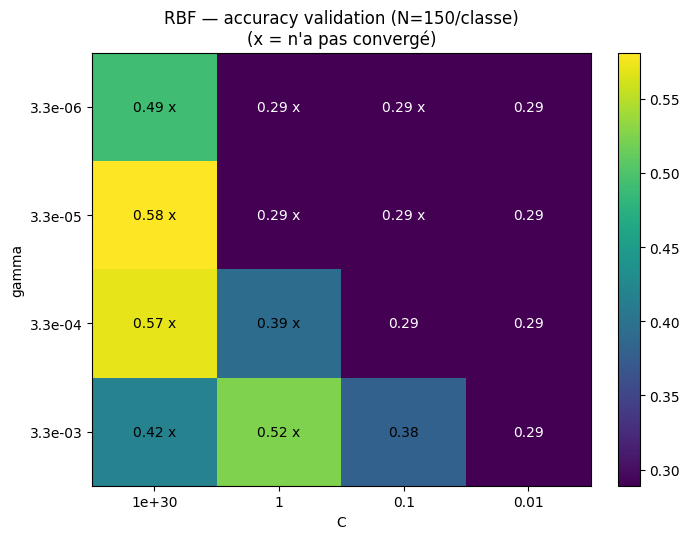

In [10]:
# Heatmap RBF (la partie la plus grande de la grille) pour visualiser
rbf_resultats = [r for r in resultats_recherche if r["kwargs"].get("kernel") == "rbf"]
acc_rbf = np.array([r["acc_val"] for r in rbf_resultats]).reshape(len(valeurs_gamma), len(valeurs_C_rbf))
conv_rbf = np.array([r["converge"] for r in rbf_resultats]).reshape(len(valeurs_gamma), len(valeurs_C_rbf))

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(acc_rbf, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(valeurs_C_rbf))); ax.set_xticklabels([f"{c:g}" for c in valeurs_C_rbf])
ax.set_yticks(range(len(valeurs_gamma))); ax.set_yticklabels([f"{g:.1e}" for g in valeurs_gamma])
ax.set_xlabel("C"); ax.set_ylabel("gamma")
ax.set_title(f"RBF — accuracy validation (N={N_CIBLE}/classe)\n(x = n'a pas convergé)")
for i in range(acc_rbf.shape[0]):
    for j in range(acc_rbf.shape[1]):
        texte = f"{acc_rbf[i,j]:.2f}" + ("" if conv_rbf[i,j] else " x")
        ax.text(j, i, texte, ha='center', va='center',
                 color='white' if acc_rbf[i,j] < acc_rbf.max()*0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("svm_recherche_exhaustive_rbf.png", dpi=130, bbox_inches='tight')
plt.show()


## Essai 4 : comparaison des configs (32x32 RGB vs 32x32 gris vs 64x64 RGB)

### Essai 4a : config 32x32 RGB (référence, déjà chargée en mémoire)

In [11]:
MEILLEUR_KERNEL = 'rbf'
MEILLEUR_GAMMA  = gamma_defaut

def entrainer_et_evaluer(config_nom, n_max_par_classe=N_MAX_PER_CLASSE, seed=77):
    rng_local = np.random.default_rng(seed)

    Xtr, ytr, Xva, yva, Xte, yte, cls = charger_config(config_nom)
    Xtr_s, ytr_s = sous_echantillonner(Xtr, ytr, n_max_par_classe, rng_local)

    gamma = MEILLEUR_GAMMA if config_nom == CONFIG else 1.0 / Xtr.shape[1]

    model = SVM_OVR(n_classes=len(cls), kernel=MEILLEUR_KERNEL, gamma=gamma, max_iter=20000)
    model.fit(Xtr_s, ytr_s)

    acc_tr = model.accuracy(Xtr_s, ytr_s)
    acc_va = model.accuracy(Xva, yva)
    return model, Xva, yva, cls, acc_tr, acc_va

model_rgb, Xval_rgb, yval_rgb, _, acc_tr_rgb, acc_va_rgb = entrainer_et_evaluer("32x32_rgb")
print(f"32x32 RGB  : acc_train={acc_tr_rgb*100:.1f}%   acc_val={acc_va_rgb*100:.1f}%")

Config     : 32x32_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 3072)  y_train : (4960,)
  X_val   : (1062, 3072)    y_val   : (1062,)
  X_test  : (1066, 3072)   y_test  : (1066,)
  n_features = 3072
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

32x32 RGB  : acc_train=98.9%   acc_val=58.4%


### Essai 4b : config 32x32 niveaux de gris

In [12]:
model_gris, Xval_gris, yval_gris, _, acc_tr_gris, acc_va_gris = entrainer_et_evaluer("32x32_gris")
print(f"32x32 gris : acc_train={acc_tr_gris*100:.1f}%   acc_val={acc_va_gris*100:.1f}%")


Config     : 32x32_gris
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 1024)  y_train : (4960,)
  X_val   : (1062, 1024)    y_val   : (1062,)
  X_test  : (1066, 1024)   y_test  : (1066,)
  n_features = 1024
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

32x32 gris : acc_train=98.0%   acc_val=46.7%


### Essai 4c : config 64x64 RGB

In [13]:
model_64, Xval_64, yval_64, _, acc_tr_64, acc_va_64 = entrainer_et_evaluer("64x64_rgb")
print(f"64x64 RGB  : acc_train={acc_tr_64*100:.1f}%   acc_val={acc_va_64*100:.1f}%")


Config     : 64x64_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 12288)  y_train : (4960,)
  X_val   : (1062, 12288)    y_val   : (1062,)
  X_test  : (1066, 12288)   y_test  : (1066,)
  n_features = 12288
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

64x64 RGB  : acc_train=99.8%   acc_val=59.4%


### Récapitulatif des 3 configs

In [14]:
print(f"32x32 RGB  : acc_train={acc_tr_rgb*100:.1f}%   acc_val={acc_va_rgb*100:.1f}%")
print(f"32x32 gris : acc_train={acc_tr_gris*100:.1f}%   acc_val={acc_va_gris*100:.1f}%")
print(f"64x64 RGB  : acc_train={acc_tr_64*100:.1f}%   acc_val={acc_va_64*100:.1f}%")


32x32 RGB  : acc_train=98.9%   acc_val=58.4%
32x32 gris : acc_train=98.0%   acc_val=46.7%
64x64 RGB  : acc_train=99.8%   acc_val=59.4%


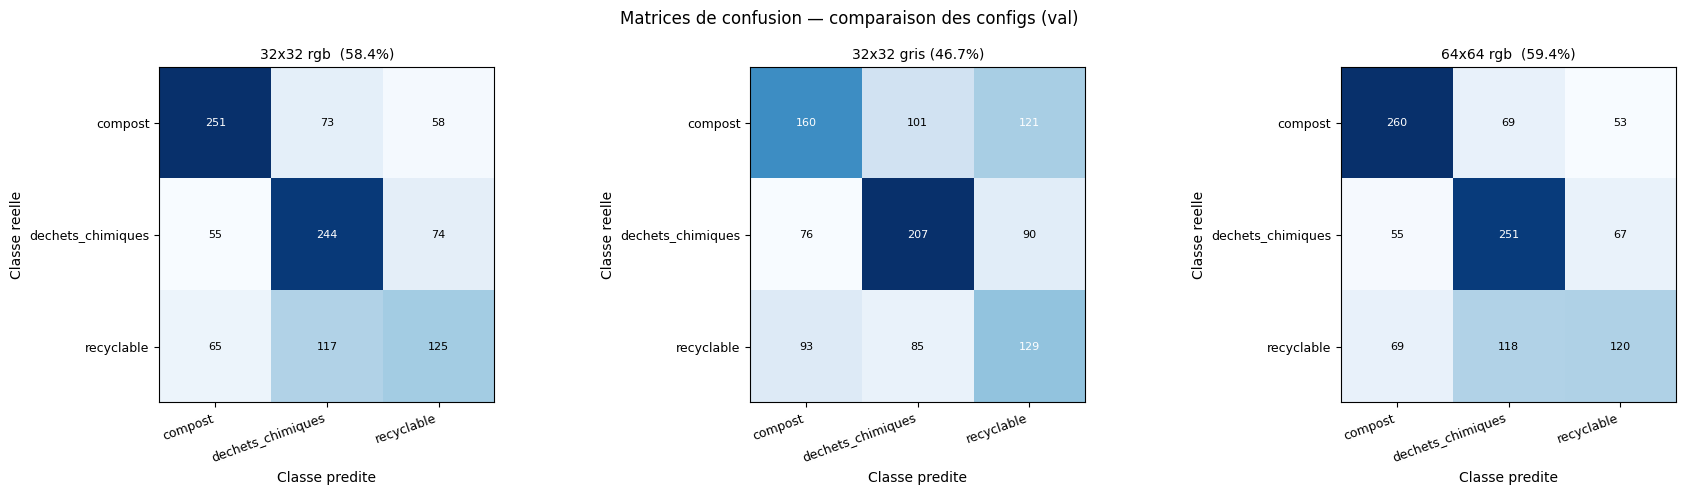

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de confusion — comparaison des configs (val)", fontsize=12)

configs_cm = [
    (model_rgb,  Xval_rgb,  yval_rgb,  f"32x32 rgb  ({acc_va_rgb*100:.1f}%)"),
    (model_gris, Xval_gris, yval_gris, f"32x32 gris ({acc_va_gris*100:.1f}%)"),
    (model_64,   Xval_64,   yval_64,   f"64x64 rgb  ({acc_va_64*100:.1f}%)"),
]

for ax, (model, Xv, yv, titre) in zip(axes, configs_cm):
    cm = model.confusion_matrix(Xv, yv)
    afficher_matrice_confusion(cm, titre, classes, ax=ax)

plt.tight_layout()
plt.savefig("svm_exp_configs_confusion.png", dpi=130, bbox_inches='tight')
plt.show()


## Notes pour le rapport

- SVM hard margin : pas de `C`, suppose les données séparables.
- Coût `O(n²)` par itération → sous-échantillonnage nécessaire.
- Nombre de vecteurs supports = complexité du modèle.

# Sélection finale du modèle

## Déséquilibre des classes

Le jeu d'entraînement n'est pas équilibré. Le sous-échantillonnage équilibre artificiellement les classes, mais le jeu de test reste déséquilibré.

## Réentraînement du modèle final (64x64 RGB)

On utilise la config **64x64 RGB** pour le modèle final (meilleure résolution).
Entraînement sur plusieurs graines, on retient la médiane.

In [16]:
# Charger le dataset 64x64 RGB pour le modèle final
CONFIG_FINAL = "64x64_rgb"
X_train_64, y_train_64, X_val_64, y_val_64, X_test_64, y_test_64, classes_64 = charger_config(CONFIG_FINAL)

N_FEATURES_64 = X_train_64.shape[1]
print(f"Config finale : {CONFIG_FINAL} ({N_FEATURES_64} features)")

N_MAX_PER_CLASSE_FINAL = N_MAX_PER_CLASSE
MAX_ITER_FINAL = 200000

candidats_finaux = []
for graine in [2026, 7, 123]:
    rng_final = np.random.default_rng(graine)
    X_tr, y_tr = sous_echantillonner(X_train_64, y_train_64, N_MAX_PER_CLASSE_FINAL, rng_final)

    if MEILLEUR_NORMALISER:
        X_tr_k = normaliser_l2(X_tr)
    else:
        X_tr_k = X_tr

    m = SVM_OVR(n_classes=N_CLASSES, max_iter=MAX_ITER_FINAL, **MEILLEURS_PARAMS)
    m.fit(X_tr_k, y_tr)

    acc_tr = m.accuracy(X_tr_k, y_tr)
    acc_va = m.accuracy(normaliser_l2(X_val_64) if MEILLEUR_NORMALISER else X_val_64, y_val_64)
    candidats_finaux.append((graine, m, X_tr, y_tr, acc_tr, acc_va))
    print(f"graine={graine:<6} acc_train={acc_tr*100:5.1f}%  acc_val={acc_va*100:5.1f}%  "
          f"nsv={m.n_support_vectors()}  iterations={m.n_iterations_used()}")

candidats_finaux.sort(key=lambda c: c[5])
graine_retenue, modele_final, X_train_final, y_train_final, acc_train_final, acc_val_final = candidats_finaux[1]

if MEILLEUR_NORMALISER:
    X_train_final_k = normaliser_l2(X_train_final)
    X_val_k         = normaliser_l2(X_val_64)
    X_test_k        = normaliser_l2(X_test_64)
else:
    X_train_final_k = X_train_final
    X_val_k         = X_val_64
    X_test_k        = X_test_64

# Mettre à jour y_test pour le 64x64
y_test = y_test_64

print(f"\nModele retenu (mediane) : graine={graine_retenue}")
print(f"acc_train : {acc_train_final*100:.1f}%")
print(f"acc_val   : {acc_val_final*100:.1f}%")
print(f"vecteurs supports par classe : {modele_final.n_support_vectors()}")
print(f"iterations par classe        : {modele_final.n_iterations_used()}")

graine=2026   acc_train= 99.8%  acc_val= 48.3%  nsv=[298, 319, 333]  iterations=[200000, 200000, 200000]
graine=7      acc_train= 91.6%  acc_val= 41.6%  nsv=[270, 307, 343]  iterations=[200000, 200000, 200000]
graine=123    acc_train= 99.8%  acc_val= 51.1%  nsv=[294, 319, 319]  iterations=[200000, 200000, 200000]

Modele retenu (mediane des 3 graines) : graine=2026
acc_train : 99.8%
acc_val   : 48.3%
vecteurs supports par classe : [298, 319, 333]
iterations par classe        : [200000, 200000, 200000]


In [17]:
iterations = modele_final.n_iterations_used()
nsv = modele_final.n_support_vectors()
n_total = X_train_final_k.shape[0]

pas_converge = [i for i, it in enumerate(iterations) if it >= MAX_ITER_FINAL]

if pas_converge:
    print(f"Limite : {len(pas_converge)}/{N_CLASSES} classifieur(s) n'ont pas converge ({MAX_ITER_FINAL} iterations).")
    print(f"Vecteurs supports : {nsv} sur {n_total} exemples.")
else:
    print(f"OK : les {N_CLASSES} classifieurs ont tous converge.")
    print(f"Vecteurs supports : {nsv} sur {n_total} exemples.")

ATTENTION : 3/3 classifieur(s) n'ont PAS converge (plafond de 200000 iterations atteint).
Vecteurs supports : [298, 319, 333] sur 450 exemples (['66%', '71%', '74%']) -- proche de 100% = mauvais signe.

Ce modele n'est probablement PAS fiable a sauvegarder tel quel. Options :
  1. Reduire N_MAX_PER_CLASSE_FINAL (actuellement 150) pour revenir a une taille ou ca convergeait (ex: 100-150).
  2. Choisir un gamma plus grand dans MEILLEURS_PARAMS (un gamma tres petit = noyau tres lisse = plus dur a separer parfaitement a grande echelle).
  3. Augmenter MAX_ITER_FINAL (mais deja a 200000, risque d'etre tres long).


## Évaluation finale sur le jeu de test

In [18]:
acc_test_final = modele_final.accuracy(X_test_k, y_test)
print(f"=== RESULTAT FINAL (test, jamais vu avant) ===")
print(f"Config retenue : {meilleur_nom}")
print(f"acc_test = {acc_test_final*100:.1f}%")


=== RESULTAT FINAL (test, jamais vu avant) ===
Config retenue : linear hard margin
acc_test = 48.9%


compost              : 384 exemples de test, 230 bien classes (59.9%)
dechets_chimiques    : 374 exemples de test, 145 bien classes (38.8%)
recyclable           : 308 exemples de test, 146 bien classes (47.4%)


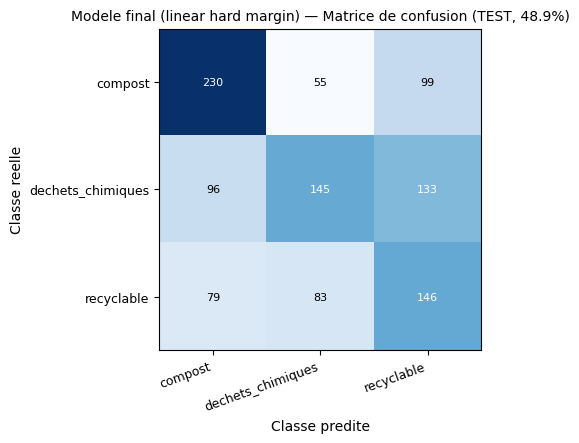

In [19]:
cm_test = modele_final.confusion_matrix(X_test_k, y_test)
afficher_matrice_confusion(
    cm_test,
    f"Modele final ({meilleur_nom}) — Matrice de confusion (TEST, {acc_test_final*100:.1f}%)",
    classes
)
plt.tight_layout()

# Rappel du desequilibre du jeu de test (cf. note plus haut)
for i, nom_classe in enumerate(classes):
    total_reel = cm_test[i].sum()
    print(f"{nom_classe:20s} : {total_reel} exemples de test, "
          f"{cm_test[i,i]} bien classes ({cm_test[i,i]/total_reel*100:.1f}%)")

plt.savefig("svm_final_test_confusion.png", dpi=130, bbox_inches='tight')
plt.show()


## Illustrations pour le rapport

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Train', 'Validation', 'Test']
valeurs = [acc_train_final*100, acc_val_final*100, acc_test_final*100]
couleurs = ['steelblue', 'orange', 'green']
bars = ax.bar(labels, valeurs, color=couleurs, alpha=0.85, width=0.55)
for bar, v in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title(f"SVM dual {meilleur_nom} — écart train/val/test\n"
             f"(N={N_MAX_PER_CLASSE_FINAL} exemples/classe, {meilleur_nom.split(' ')[0]})")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("svm_fig_train_val_test.png", dpi=150, bbox_inches='tight')
plt.show()


Modele sauvegarde : svm_final_dechets.txt (53520.4 Ko, fichier texte unique)
Config : linear hard margin | acc_test = 48.9%


/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets/svm_final_dechets.txt

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
accuracy_par_classe = [cm_test[i, i] / cm_test[i].sum() * 100 for i in range(N_CLASSES)]
n_par_classe = [cm_test[i].sum() for i in range(N_CLASSES)]

bars = ax.bar(classes, accuracy_par_classe, color='steelblue', alpha=0.85, width=0.55)
ax.axhline(100 / N_CLASSES, color='red', linestyle='--', linewidth=1,
           label=f'hasard ({100/N_CLASSES:.1f}%, {N_CLASSES} classes)')
for bar, v, n in zip(bars, accuracy_par_classe, n_par_classe):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}%\n(n={n})", ha='center', fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, max(accuracy_par_classe) + 15)
ax.set_title(f"SVM dual {meilleur_nom} — accuracy par classe (test)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("svm_fig_par_classe.png", dpi=150, bbox_inches='tight')
plt.show()


## Sauvegarde du modèle final

In [27]:
NOM_FICHIER_MODELE = "svm_final_dechets.txt"

modele_final.save(NOM_FICHIER_MODELE)

import os
taille_ko = os.path.getsize(NOM_FICHIER_MODELE) / 1024
print(f"Modele sauvegarde : {NOM_FICHIER_MODELE} ({taille_ko:.1f} Ko, fichier texte unique)")
print(f"Config : {meilleur_nom} | acc_test = {acc_test_final*100:.1f}%")

from IPython.display import FileLink
FileLink(NOM_FICHIER_MODELE)


Modele sauvegarde : svm_final_dechets.txt (53520.4 Ko, fichier texte unique)
Config : linear hard margin | acc_test = 48.9%


/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets/svm_final_dechets.txt

### Vérification du modèle rechargé

In [28]:
modele_recharge = SVM_OVR.load(NOM_FICHIER_MODELE)

acc_test_recharge = modele_recharge.accuracy(X_test_k, y_test)
print(f"acc_test (modele recharge) : {acc_test_recharge*100:.1f}%  "
      f"(attendu : {acc_test_final*100:.1f}%)")

assert np.allclose(acc_test_recharge, acc_test_final), "Le modele recharge ne correspond pas !"
print("OK : le modele recharge depuis le fichier est identique au modele entraine.")


acc_test (modele recharge) : 48.9%  (attendu : 48.9%)
OK : le modele recharge depuis le fichier est identique au modele entraine.


## Bilan

- **Modèle** : hard margin linéaire
- **Performance** : `acc_test_final`
- **Export** : `svm_final_dechets.txt`